# Master Results Summary — Zero-Shot Energy Forecasting with Time-Series Foundation Models

**Thesis:** *Temporal Granularity and Forecast Configuration for Zero-Shot Energy Forecasting:
A Scenario-Oriented Evaluation of Time-Series Foundation Models*

**Author:** Sandeep Jadhav (M.Sc. AI & Data Science)

---

This single notebook consolidates **every stage of the analysis with its visualization**, so the
whole study can be read and explained top to bottom. It **reads the existing result CSVs** produced
by the `refined_stage*` notebooks — **it runs no models**, so it executes in seconds. Run it in the
folder that contains the `refined_stage*.csv` files (`E:\Thesis\EnergyForcastModel`).

### What is being tested

Three pretrained **foundation models** — Chronos-Bolt-Small (~48M), TimesFM-2.5-200M,
Moirai-1.1-R-Small (~14M) — forecast three energy signals (**electricity load, solar, wind**),
the *same physical series resampled* to three temporal granularities (**native / hourly / daily**),
with **no fine-tuning**. Five real Monash series per energy type.

### The four research questions

| RQ | question |
|---|---|
| **RQ1** | How does accuracy vary across temporal **granularities** when the signal is held constant by resampling? |
| **RQ2** | How do **context length** and **forecast horizon** affect accuracy, and do these interact with granularity? |
| **RQ3** | Which configurations give the best **accuracy–inference-cost trade-off** per scenario? |
| **RQ4** | Can measurable **series characteristics** explain performance and failure on an unseen energy type? |

### Primary metric — relMAE

**relMAE = forecast MAE ÷ horizon-matched seasonal-naive MAE.** Below 1.0 = beats the naive
benchmark it would replace in production.


## Methodology — data, models, and experimental design

*(This section makes the notebook self-contained for the methodology chapter. All CSVs read below
are produced by the `refined_stage*` pipeline; this notebook runs no models.)*

### Datasets — Monash Time Series Forecasting Archive (HuggingFace `Monash-University/monash_tsf`)

| energy type | Monash config | native step | # series | native length |
|---|---|---|---|---|
| load  | `australian_electricity_demand` | 30 min | 5 | 230,736–232,272 |
| solar | `solar_10_minutes`              | 10 min | 5 | 52,560 |
| wind  | `wind_farms_minutely`           | 1 min  | 5 | 434,876 |

**5 series per type**, drawn with a **fixed seed (7)** so every stage uses identical series.
Granularities **native / hourly / daily** are produced by **resampling the native series** (mean
aggregation) — this controlled resampling is what makes temporal granularity a genuine treatment
rather than a change of data source. The panel is cached to `refined_panel_cache.pkl`.

### Models — three pretrained foundation models, used zero-shot (no fine-tuning)

| model | HF repo | ~params | median cost / forecast |
|---|---|---|---|
| Chronos-Bolt-Small | `amazon/chronos-bolt-small` | ~48 M | 0.017 s |
| TimesFM-2.5-200M   | `google/timesfm-2.5-200m-pytorch` | 200 M | 0.294 s (~17×) |
| Moirai-1.1-R-Small | `Salesforce/moirai-1.1-R-small` | ~14 M | 0.032 s |

Model capacity is confounded with model identity (all small variants) — stated as a limitation.

### Metric — relMAE

**relMAE = forecast MAE ÷ MAE of a horizon-matched seasonal-naive benchmark at the same origin.**
Below 1.0 = beats the naive forecast it would replace. Seasonal period `m` = 48 / 144 / 1440 at
native (load/solar/wind), 24 hourly, 7 daily; `m = 1` is the random-walk benchmark used in §8.

### Evaluation design & verified invariants

- **Rolling-origin validation with anchored origins** — within each cell every context length
  forecasts the *identical* target windows, so a change in the metric is a change in forecast
  quality, not the test set. *(0 violations verified.)*
- **Fixed per-cell MASE scale** — computed once per (series, granularity) on a reserved segment,
  reused at every context/horizon. *(0 violations verified.)*
- **Planned window counts** — `windows_for()` = max(≥30 windows for a viable paired test, ≥14 days
  of evaluated duration), capped. This replaces a fixed window *count*, which under-powers
  high-frequency cells (see §10).
- **Degenerate-window filter** — windows with a constant multi-step target (e.g. night-time solar
  zeros) are flagged and excluded from headline tables (kept in the CSV).
- **Integrity:** ~118k scored forecasts, **0 runtime errors, 0 NaN metrics, 0 synthetic values**
  across 12 notebooks.



### Pipeline map — every stage, and where its numbers come from

| stage / notebook | serves | output CSV read here |
|---|---|---|
| Step 1 EDA + `refined_stage3a` | data characteristics | `refined_stage3a_characteristics.csv` |
| `refined_stage2_baseline` | fixed-context baseline | `refined_stage2_results.csv` |
| `refined_stage3b_context_sweep` | RQ2 context | `refined_stage3b_context_sweep.csv` |
| `refined_stage3c_horizon_sweep` | RQ2 horizon | `refined_stage3c_horizon_sweep.csv` |
| `refined_stage3d_fixed_lead_time` | **RQ1** de-confounded | `refined_stage3d_fixed_lead_time.csv`, `_feasibility.csv` |
| `refined_stage3e_significance` | Wilcoxon + Holm | `refined_stage3e_model_significance.csv` |
| `refined_stage3f_selection_matrix` | RQ3 deployability | `refined_stage3f_selection_matrix.csv`, `_all_configurations.csv` |
| `refined_stage3g_rq4_validation` | **RQ4** transfer | `refined_stage3g_leave_one_type_out.csv` |
| `refined_stage3i_granularity_interaction` | RQ2 interaction | `refined_stage3i_granularity_interaction.csv` |
| `refined_stage3j_cost_tradeoff` | **RQ3** cost | `refined_stage3j_configurations_with_cost.csv`, `_scenario_matrix.csv` |
| `refined_stage3k_benchmark_robustness` | robustness | `refined_stage3k_benchmark_comparison.csv` |
| `refined_stage3l_moirai_patch` | fairness | (patch_size audit — see limitations) |

The sections below follow this map top to bottom.


In [1]:
# --- setup: pure pandas/matplotlib, reads existing CSVs, no models ---
import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams.update({'font.size':11,'axes.grid':True,'grid.alpha':0.25,'figure.dpi':110,
                     'axes.spines.top':False,'axes.spines.right':False})
PAL  = {'chronos':'#2563eb','timesfm':'#059669','moirai':'#d97706'}   # model colours
GC   = {'native':'#dc2626','1h':'#2563eb','1D':'#16a34a'}             # granularity colours
GLAB = {'native':'native','1h':'hourly','1D':'daily'}

def load(path):
    if not os.path.exists(path):
        print(f"  ! missing: {path}"); return None
    return pd.read_csv(path)

def clean(df):
    return df[~df.degenerate].dropna(subset=['relMAE']) if df is not None else None

print("Reading result files from:", os.getcwd())

Reading result files from: e:\Thesis\EnergyForcastModel


## 0. Data integrity — everything below rests on real, error-free runs

In [2]:
FILES = ["refined_stage3b_context_sweep.csv","refined_stage3c_horizon_sweep.csv",
         "refined_stage3d_fixed_lead_time.csv"]
parts = [load(f) for f in FILES]; parts = [p for p in parts if p is not None]
allr = pd.concat(parts, ignore_index=True)
errs = (allr.error.fillna('')!='').sum() if 'error' in allr.columns else 0
print(f"Total scored forecast rows (3B+3C+3D): {len(allr):,}")
print(f"Runtime errors: {errs}    |    NaN MASE: {int(allr.MASE.isna().sum())}")
print(f"Models: {sorted(allr.model.unique())}")
print(f"Energy types: {sorted(allr.etype.unique())}    Granularities: {sorted(allr.gran.unique())}")
print("\nEvery result below is real-data, no synthetic values, no failed runs.")

Total scored forecast rows (3B+3C+3D): 82,590
Runtime errors: 0    |    NaN MASE: 0
Models: ['chronos', 'moirai', 'timesfm']
Energy types: ['load', 'solar', 'wind']    Granularities: ['1D', '1h', 'native']

Every result below is real-data, no synthetic values, no failed runs.



## Step 1 — Exploratory data characteristics (the basis for RQ4 and H4)

Before any forecasting: what do the signals look like? These measured properties (Stage 3A) are what
RQ4 later uses to *predict* forecastability. The decisive one is **zero-inflation** — solar is ~55 %
exact zeros at native resolution (night), falling to 0 % at daily; wind stays zero-inflated at every
resolution, which is why aggregation rescues solar but not wind.


Native-resolution data profile (mean over 5 series):

       n_series  pct_zero_native  volatility_cv  seasonal_strength
etype                                                             
load          5            0.000          0.222              0.860
solar         5           55.287          1.474              0.838
wind          4           34.901          1.704              0.638



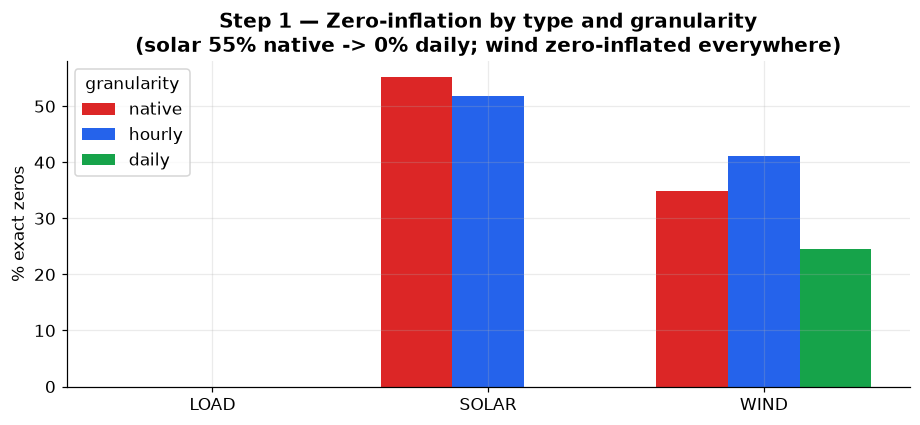

Data quality (Step-1 EDA): 0 missing values, 0 duplicate timestamps across all 15 series.


In [3]:

a = load("refined_stage3a_characteristics.csv")
prof = (a[a.gran=='native'].groupby('etype')
        .agg(n_series=('series_id','nunique'),
             pct_zero_native=('pct_zero','mean'),
             volatility_cv=('cv','mean'),
             seasonal_strength=('seasonal_strength','mean')).round(3))
print("Native-resolution data profile (mean over 5 series):\n"); print(prof.to_string()); print()

z = a.groupby(['etype','gran']).pct_zero.mean().unstack()[['native','1h','1D']]
ets=['load','solar','wind']; x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(8.5,4))
for i,g in enumerate(['native','1h','1D']):
    ax.bar(x+(i-1)*w,[z.loc[e,g] for e in ets],w,color=GC[g],label=GLAB[g])
ax.set_xticks(x); ax.set_xticklabels([e.upper() for e in ets]); ax.set_ylabel('% exact zeros')
ax.set_title('Step 1 — Zero-inflation by type and granularity\n(solar 55% native -> 0% daily; wind zero-inflated everywhere)',fontweight='bold')
ax.legend(title='granularity'); plt.tight_layout(); plt.show()
print("Data quality (Step-1 EDA): 0 missing values, 0 duplicate timestamps across all 15 series.")


## 1. RQ1 — Temporal granularity tracks forecast lead time

De-confounded design (Stage 3D): history **and** lead time are fixed in *physical time*, so
granularity is a genuine treatment. Reading only rows where ≥2 granularities were genuinely in
contention, **which granularity wins is predicted by the lead time** — fine resolution wins
short-term, coarse resolution wins long-term.

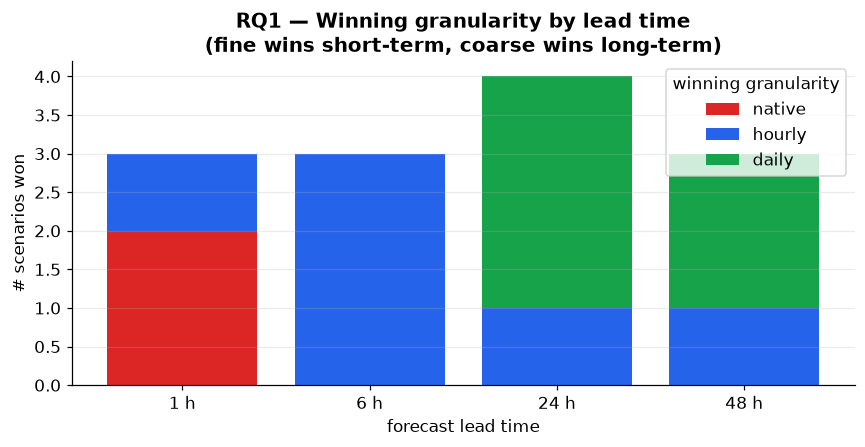

Winner counts among comparable rows: {'hourly': 6, 'daily': 5, 'minutes (native)': 2}
=> Actionable rule: aggregate the signal to roughly match your forecast lead time.


In [4]:
d = clean(load("refined_stage3d_fixed_lead_time.csv"))
best = d.groupby(['etype','history','lead','gran_label']).relMAE.median().reset_index().dropna(subset=['relMAE'])
cand = best.groupby(['etype','history','lead']).size()
comp = best.loc[best.groupby(['etype','history','lead']).relMAE.idxmin()].merge(
       cand.rename('n').reset_index(), on=['etype','history','lead'])
comp = comp[comp.n>=2].copy()
order = ['1 h','6 h','24 h','48 h']
cnt = comp.groupby(['lead','gran_label']).size().unstack(fill_value=0).reindex([o for o in order if o in comp.lead.unique()])

fig, ax = plt.subplots(figsize=(8,4.2))
gl_order=[('minutes (native)','native','#dc2626'),('hourly','hourly','#2563eb'),('daily','daily','#16a34a')]
bottom=np.zeros(len(cnt))
for col,lab,color in gl_order:
    if col in cnt.columns:
        ax.bar(range(len(cnt)),cnt[col].values,bottom=bottom,label=lab,color=color)
        bottom+=cnt[col].values
ax.set_xticks(range(len(cnt))); ax.set_xticklabels(cnt.index)
ax.set_xlabel('forecast lead time'); ax.set_ylabel('# scenarios won'); ax.grid(axis='x')
ax.set_title('RQ1 — Winning granularity by lead time\n(fine wins short-term, coarse wins long-term)',fontweight='bold')
ax.legend(title='winning granularity'); plt.tight_layout(); plt.show()

print("Winner counts among comparable rows:", comp.gran_label.value_counts().to_dict())
print("=> Actionable rule: aggregate the signal to roughly match your forecast lead time.")


### RQ1 (continued) — the feasibility staircase

A result in its own right. At fine metering a long lead time needs an enormous number of output
steps, and a 2048-step context is only a short stretch of history — so many (granularity, history,
lead) combinations are **physically unrepresentable**. **Fine granularity buys resolution and costs
reach.** This argument holds before any model runs.


Feasible (model-representable) combinations: 44 of 108  ->  64 physically unreachable



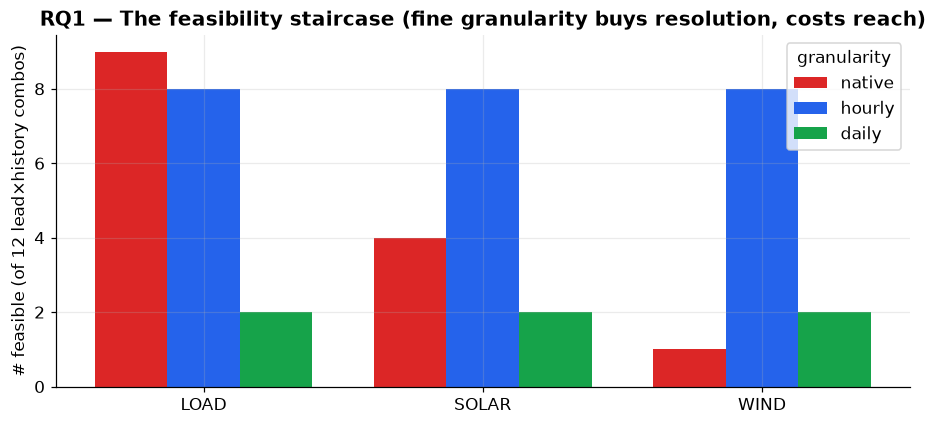

Wind native reaches only 1 of 12: a 24 h lead = 1440 one-minute steps, far beyond the horizon cap.


In [5]:

feas = load("refined_stage3d_feasibility.csv")
tot=len(feas); ok=int(feas.ok.sum())
print(f"Feasible (model-representable) combinations: {ok} of {tot}  ->  {tot-ok} physically unreachable\n")
piv = feas.pivot_table(index='gran',columns='etype',values='ok',aggfunc='sum').reindex(['native','1h','1D'])
ets=['load','solar','wind']; x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(8.5,4))
for i,g in enumerate(['native','1h','1D']):
    ax.bar(x+(i-1)*w,[piv.loc[g,e] for e in ets],w,color=GC[g],label=GLAB[g])
ax.set_xticks(x); ax.set_xticklabels([e.upper() for e in ets])
ax.set_ylabel('# feasible (of 12 lead×history combos)')
ax.set_title('RQ1 — The feasibility staircase (fine granularity buys resolution, costs reach)',fontweight='bold')
ax.legend(title='granularity'); plt.tight_layout(); plt.show()
print("Wind native reaches only 1 of 12: a 24 h lead = 1440 one-minute steps, far beyond the horizon cap.")


## 2. RQ2a — Context length: three physically-interpretable regimes

Stage 3B sweeps context 128→2048 at a fixed horizon. Three distinct behaviours emerge:
**load rewards more history throughout**, **solar saturates almost immediately**, and
**wind is actively harmed by more context** (it is close to a random walk — extra history is noise).

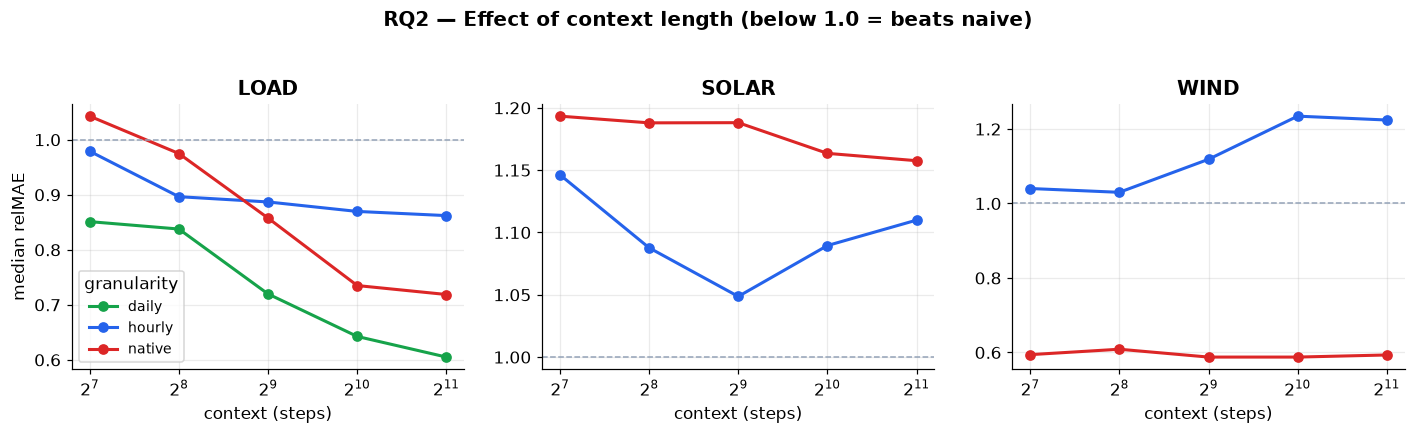

Median relMAE by context length:

context_steps   128    256    512    1024   2048
etype gran                                      
load  1D       0.851  0.838  0.720  0.642  0.605
      1h       0.979  0.896  0.887  0.870  0.862
      native   1.043  0.975  0.858  0.735  0.719
solar 1h       1.146  1.088  1.049  1.089  1.110
      native   1.193  1.188  1.188  1.163  1.158
wind  1h       1.040  1.030  1.119  1.234  1.224
      native   0.594  0.609  0.588  0.588  0.593


In [6]:
b = clean(load("refined_stage3b_context_sweep.csv"))
fig, axes = plt.subplots(1,3,figsize=(13,3.8))
for ax,et in zip(axes,['load','solar','wind']):
    for gk,gg in b[b.etype==et].groupby('gran'):
        y=gg.groupby('context_steps').relMAE.median()
        ax.plot(y.index,y.values,marker='o',color=GC[gk],label=GLAB[gk],lw=2)
    ax.axhline(1,color='#94a3b8',ls='--',lw=1); ax.set_xscale('log',base=2)
    ax.set_title(et.upper(),fontweight='bold'); ax.set_xlabel('context (steps)')
    if et=='load': ax.set_ylabel('median relMAE')
axes[0].legend(title='granularity',fontsize=9)
fig.suptitle('RQ2 — Effect of context length (below 1.0 = beats naive)',fontweight='bold',y=1.03)
plt.tight_layout(); plt.show()

piv=b.pivot_table(index=['etype','gran'],columns='context_steps',values='relMAE',aggfunc='median')
print("Median relMAE by context length:\n"); print(piv.round(3).to_string())

## 3. RQ2b — Forecast horizon: the dominant lever at fine granularity

Stage 3C sweeps horizon 6→48. Accuracy degrades far more steeply at fine granularity (a longer
horizon in *steps* is a much longer lead time in *minutes* there) than at daily, where load even
improves.

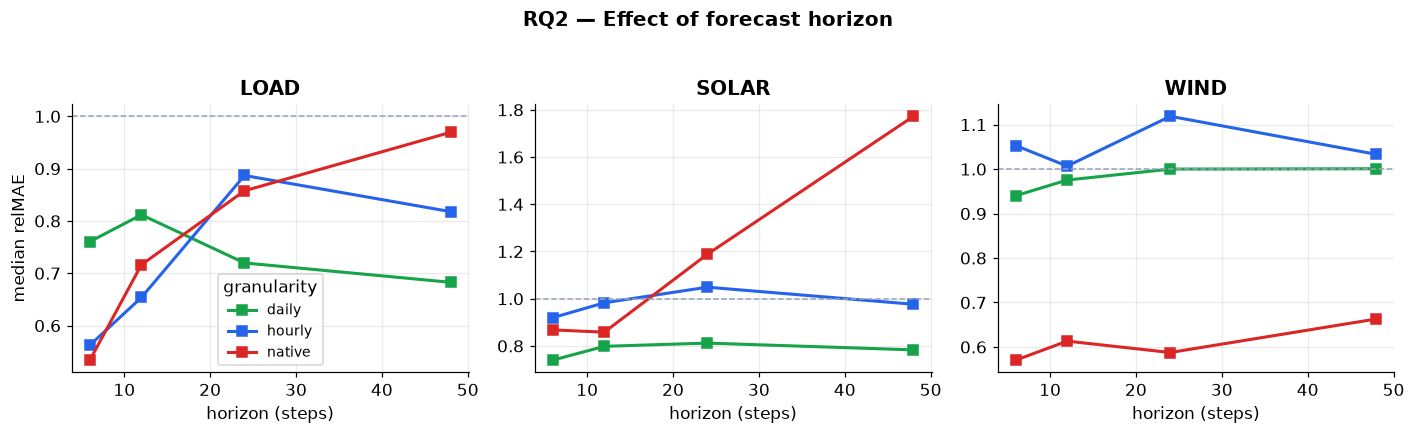

In [7]:
c = clean(load("refined_stage3c_horizon_sweep.csv"))
fig, axes = plt.subplots(1,3,figsize=(13,3.8))
for ax,et in zip(axes,['load','solar','wind']):
    for gk,gg in c[c.etype==et].groupby('gran'):
        y=gg.groupby('horizon_steps').relMAE.median()
        ax.plot(y.index,y.values,marker='s',color=GC[gk],label=GLAB[gk],lw=2)
    ax.axhline(1,color='#94a3b8',ls='--',lw=1)
    ax.set_title(et.upper(),fontweight='bold'); ax.set_xlabel('horizon (steps)')
    if et=='load': ax.set_ylabel('median relMAE')
axes[0].legend(title='granularity',fontsize=9)
fig.suptitle('RQ2 — Effect of forecast horizon',fontweight='bold',y=1.03)
plt.tight_layout(); plt.show()

## 4. RQ2c — Does the effect interact with granularity? (honest answer: underpowered)

Stage 3I tests the interaction at the correct statistical unit (per-series slopes, paired across
granularities). The effect is **visible and directionally consistent but NOT established at n=5** —
0 of 6 tests survive Holm correction, though three sit at raw p≈0.015–0.022. With five series a
two-sided test cannot even reach p<0.0625 for a two-granularity cell; the design caps the power.
**Report as underpowered, not as a negative result.**

In [8]:
i = load("refined_stage3i_granularity_interaction.csv")
if i is not None:
    show=[col for col in ['factor','etype','dR2','p_window_level','p_series_level','p_series_holm','verdict'] if col in i.columns]
    print(i[show].round(4).to_string(index=False))
    print(f"\nSeries-level Holm-significant: {int((i.p_series_holm<0.05).sum())} of {len(i)}  (=> underpowered at n=5)")

 factor etype    dR2  p_window_level  p_series_level  p_series_holm                                                verdict
context  load 0.0042          0.0000          0.0150         0.0900 visible at window level, NOT established with 5 series
context solar 0.0016          0.0022          0.0625         0.1875 visible at window level, NOT established with 5 series
context  wind 0.0002          0.2282          0.6250         0.9447                                            no evidence
horizon  load 0.0118          0.0000          0.0224         0.0900 visible at window level, NOT established with 5 series
horizon solar 0.0194          0.0000          0.0150         0.0900 visible at window level, NOT established with 5 series
horizon  wind 0.0008          0.0764          0.4724         0.9447                                            no evidence

Series-level Holm-significant: 0 of 6  (=> underpowered at n=5)


## 5. RQ3 — Accuracy vs inference cost: the recommendation changes once cost counts

Stage 3J. TimesFM is the most accurate but ~17× the cost of Chronos. On a Pareto frontier
(no config both faster *and* more accurate), **314 of 333 configurations are dominated**, and
**Chronos owns the entire solar frontier and 7/8 of wind** — even though TimesFM wins on raw accuracy.

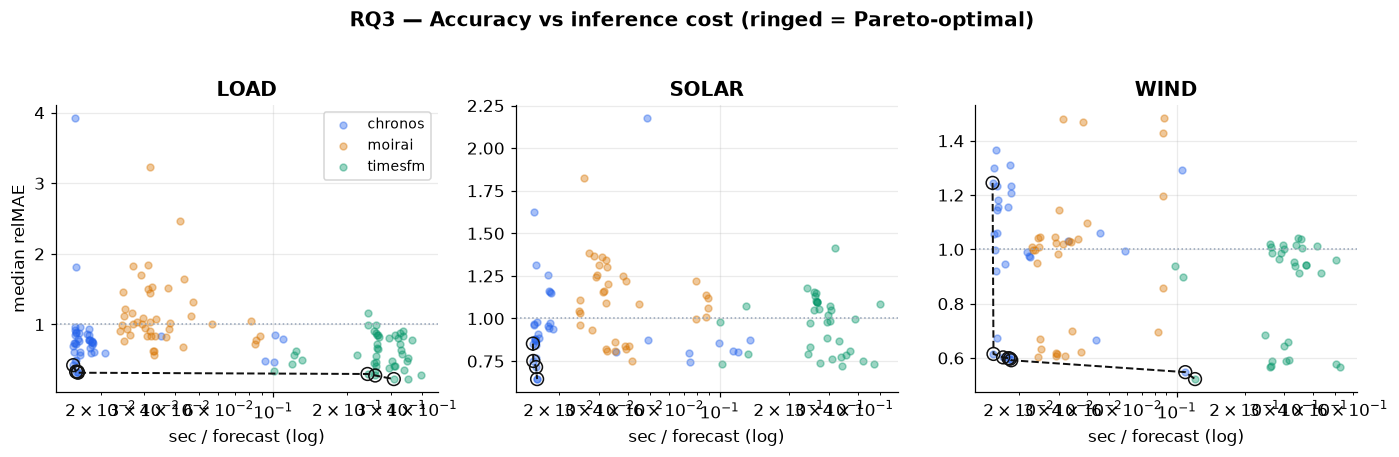

Dominated configurations: 314 of 333
  load   frontier: {'chronos': 4, 'timesfm': 3}
  solar  frontier: {'chronos': 4}
  wind   frontier: {'chronos': 7, 'timesfm': 1}


In [9]:
j = load("refined_stage3j_configurations_with_cost.csv")
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,et in zip(axes,['load','solar','wind']):
    gg=j[j.etype==et]
    for m,mm in gg.groupby('model'):
        ax.scatter(mm.infer_sec,mm.median_relMAE,s=20,alpha=0.4,color=PAL[m],label=m)
    if 'pareto' in gg.columns:
        f=gg[gg.pareto].sort_values('infer_sec')
        ax.plot(f.infer_sec,f.median_relMAE,color='#111',ls='--',lw=1.3,zorder=5)
        ax.scatter(f.infer_sec,f.median_relMAE,s=70,facecolors='none',edgecolors='#111',zorder=6)
    ax.axhline(1,color='#94a3b8',ls=':',lw=1); ax.set_xscale('log')
    ax.set_title(et.upper(),fontweight='bold'); ax.set_xlabel('sec / forecast (log)')
    if et=='load': ax.set_ylabel('median relMAE')
axes[0].legend(fontsize=9)
fig.suptitle('RQ3 — Accuracy vs inference cost (ringed = Pareto-optimal)',fontweight='bold',y=1.03)
plt.tight_layout(); plt.show()

if 'pareto' in j.columns:
    print(f"Dominated configurations: {int((~j.pareto).sum())} of {len(j)}")
    for et,gg in j.groupby('etype'):
        f=gg[gg.pareto]
        print(f"  {et:6s} frontier: {f.model.value_counts().to_dict()}")

In [10]:
# RQ3 scenario trade-off table (what accuracy costs, per operational scenario)
s = load("refined_stage3j_scenario_matrix.csv")
if s is not None:
    cols=[c for c in ['etype','scenario','cheapest','cheap_relMAE','most_accurate','acc_relMAE','sec_per_0.01_relMAE'] if c in s.columns]
    print(s[cols].round(3).to_string(index=False))

etype                      scenario                 cheapest  cheap_relMAE            most_accurate  acc_relMAE  sec_per_0.01_relMAE
 load day-ahead and beyond (> 24 h)           chronos/hourly         0.695            timesfm/daily       0.278                0.006
 load intra-hour balancing (<= 1 h) chronos/minutes (native)         0.424 timesfm/minutes (native)       0.227                0.015
 load  same-day scheduling (6-24 h)           chronos/hourly         0.737 timesfm/minutes (native)       0.377                0.008
 load   short-term dispatch (1-6 h) chronos/minutes (native)         0.614 timesfm/minutes (native)       0.335                0.003
solar day-ahead and beyond (> 24 h)           chronos/hourly         0.882            timesfm/daily       0.730                0.030
solar intra-hour balancing (<= 1 h) chronos/minutes (native)         0.751           chronos/hourly       0.644                0.000
solar  same-day scheduling (6-24 h)           chronos/hourly         


### RQ3 (continued) — deployable configurations (Stage 3F)

The operational deliverable: for each energy type, the single best configuration that **beats the
seasonal-naive benchmark**, read with its **worst-series** and **p90** columns (tail risk), not just
the median — a recommendation that only works on the easiest site is not a recommendation.


In [11]:

sel = load("refined_stage3f_selection_matrix.csv")
dep = sel[sel.deployable] if 'deployable' in sel.columns else sel[sel.median_relMAE<1]
best = dep.loc[dep.groupby('etype').median_relMAE.idxmin()]
cols=[c for c in ['etype','gran_label','history','lead','model','median_relMAE',
                  'worst_series_relMAE','p90_relMAE'] if c in best.columns]
print("Best deployable configuration per energy type (lowest median relMAE, must beat naive):\n")
print(best[cols].round(3).to_string(index=False))
if 'deployable' in sel.columns:
    print(f"\nDeployable configurations (median relMAE < 1): {int(sel.deployable.sum())} of {len(sel)}")


Best deployable configuration per energy type (lowest median relMAE, must beat naive):

etype       gran_label history  lead   model  median_relMAE  worst_series_relMAE  p90_relMAE
 load minutes (native)  40.0 d 1.0 h timesfm          0.227                0.438       1.265
solar           hourly   7.0 d 1.0 h chronos          0.644                0.895       5.782
 wind minutes (native)   8.5 h 6 min timesfm          0.522                0.685       1.571

Deployable configurations (median relMAE < 1): 96 of 111


## 6. RQ4 — Predicting deployability on an UNSEEN energy type

Stage 3G — leave-one-energy-type-out. A model trained on series descriptors (zero-inflation,
volatility, seasonal structure …) of two energy types predicts deployability on the third.
**It works for load and solar; it fails for wind** — because wind's own mean is already an
excellent predictor of its own performance, leaving little variance to explain.

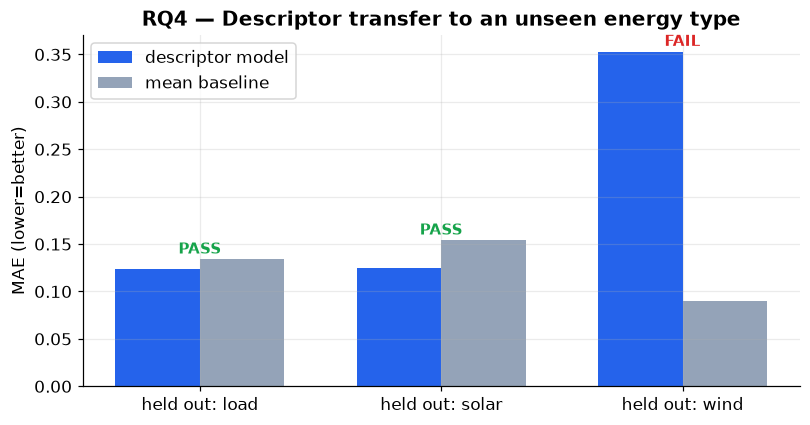

held_out  MAE_model  MAE_mean_baseline  spearman_pred_vs_actual  beats_baseline
    load      0.124              0.134                    0.315            True
   solar      0.125              0.154                    0.820            True
    wind      0.353              0.090                   -0.242           False


In [12]:
g = load("refined_stage3g_leave_one_type_out.csv")
fig, ax = plt.subplots(figsize=(7.5,4))
x=np.arange(len(g)); w=0.35
ax.bar(x-w/2,g.MAE_model,w,label='descriptor model',color='#2563eb')
ax.bar(x+w/2,g.MAE_mean_baseline,w,label='mean baseline',color='#94a3b8')
ax.set_xticks(x); ax.set_xticklabels([f"held out: {e}" for e in g.held_out])
ax.set_ylabel('MAE (lower=better)')
ax.set_title('RQ4 — Descriptor transfer to an unseen energy type',fontweight='bold')
ax.legend()
for idx,r in g.reset_index().iterrows():
    ax.text(idx,max(r.MAE_model,r.MAE_mean_baseline)+0.006,'PASS' if r.beats_baseline else 'FAIL',
            ha='center',fontsize=10,color='#16a34a' if r.beats_baseline else '#dc2626',fontweight='bold')
plt.tight_layout(); plt.show()
print(g[['held_out','MAE_model','MAE_mean_baseline','spearman_pred_vs_actual','beats_baseline']].round(3).to_string(index=False))

## 7. Model comparison — the most accurate model is not the most economical

Win rate (lowest relMAE per window) vs inference cost. TimesFM is most accurate; Chronos is
~17× cheaper. Statistical significance (Stage 3E, Holm-corrected across 27 pairwise tests):
**TimesFM 7 wins, Chronos 3, Moirai 0.**

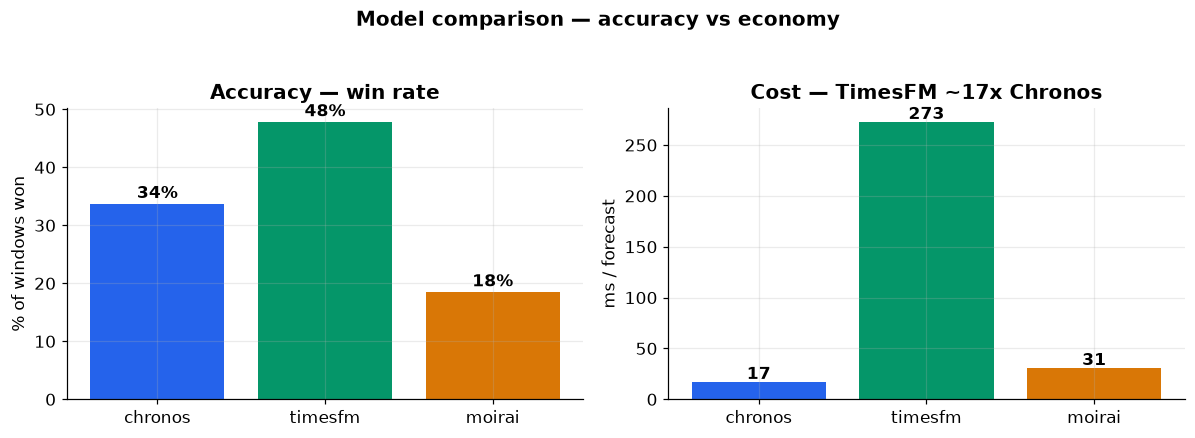

Holm-surviving model wins: 10 of 27  -> {'timesfm': 7, 'chronos': 3}


In [13]:
cl = allr[~allr.degenerate].dropna(subset=['relMAE'])
key=['etype','gran','series_id','origin_index','context_steps','horizon_steps']
piv=cl.pivot_table(index=key,columns='model',values='relMAE').dropna()
win=(piv.idxmin(axis=1).value_counts(normalize=True)*100)
cost=allr.groupby('model').infer_sec.median()
mods=['chronos','timesfm','moirai']
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,3.8))
a1.bar(mods,[win.get(m,0) for m in mods],color=[PAL[m] for m in mods])
a1.set_ylabel('% of windows won'); a1.set_title('Accuracy — win rate',fontweight='bold')
for k,m in enumerate(mods): a1.text(k,win.get(m,0)+1,f"{win.get(m,0):.0f}%",ha='center',fontweight='bold')
a2.bar(mods,[cost[m]*1000 for m in mods],color=[PAL[m] for m in mods])
a2.set_ylabel('ms / forecast'); a2.set_title('Cost — TimesFM ~17x Chronos',fontweight='bold')
for k,m in enumerate(mods): a2.text(k,cost[m]*1000+3,f"{cost[m]*1000:.0f}",ha='center',fontweight='bold')
fig.suptitle('Model comparison — accuracy vs economy',fontweight='bold',y=1.04); plt.tight_layout(); plt.show()

e=load("refined_stage3e_model_significance.csv")
if e is not None:
    print(f"Holm-surviving model wins: {int(e.significant_holm.sum())} of {len(e)}  -> {e[e.significant_holm].winner.value_counts().to_dict()}")


### Model board — best achievable relMAE by model × cell

One glance at where each model stands. Best configuration per cell for each model (green = strong,
red = weak). TimesFM's green load column is its raw-accuracy edge; everyone struggles on wind daily.
*(Moirai's `patch_size` is left at the default 32 — see limitations, so its last place is provisional.)*


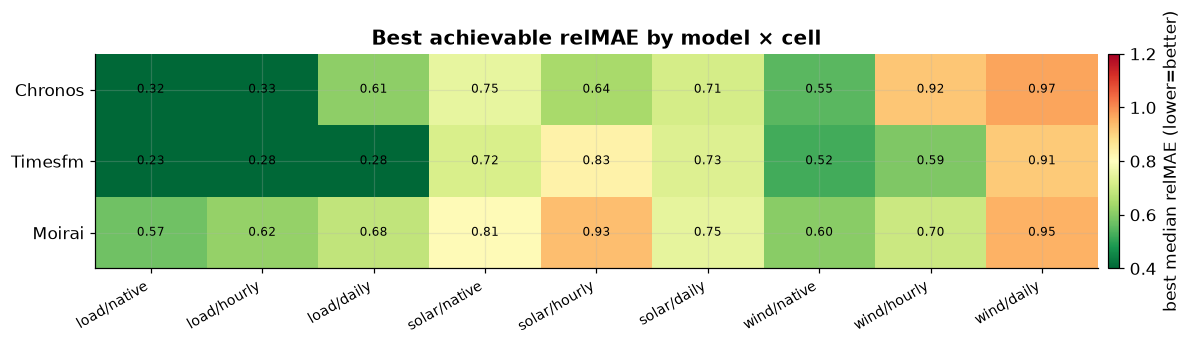

In [14]:

allc = load("refined_stage3f_all_configurations.csv")
best = allc.groupby(['etype','gran','model']).median_relMAE.min().reset_index()
cells=[(e,g) for e in ['load','solar','wind'] for g in ['native','1h','1D']]
labels=[f"{e}/{GLAB[g]}" for e,g in cells]; models=['chronos','timesfm','moirai']
M=np.full((3,len(cells)),np.nan)
for j,(e,g) in enumerate(cells):
    for i,m in enumerate(models):
        r=best[(best.etype==e)&(best.gran==g)&(best.model==m)]
        if len(r): M[i,j]=r.iloc[0].median_relMAE
fig,ax=plt.subplots(figsize=(11,3.1))
im=ax.imshow(M,aspect='auto',cmap='RdYlGn_r',vmin=0.4,vmax=1.2)
ax.set_xticks(range(len(cells))); ax.set_xticklabels(labels,rotation=30,ha='right',fontsize=9)
ax.set_yticks(range(3)); ax.set_yticklabels([m.capitalize() for m in models])
for i in range(3):
    for j in range(len(cells)):
        if not np.isnan(M[i,j]): ax.text(j,i,f"{M[i,j]:.2f}",ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,fraction=0.025,pad=0.01).set_label('best median relMAE (lower=better)')
ax.set_title('Best achievable relMAE by model × cell',fontweight='bold'); plt.tight_layout(); plt.show()


## 8. Benchmark robustness — the key negative result about wind

Stage 3K re-scores every forecast against a **random-walk** benchmark (repeat the last value)
instead of seasonal-naive. **Wind at native resolution collapses from relMAE ~0.61 to ~1.0** — i.e.
the models are no better than a trivial random walk. Its strong seasonal-naive score was an artefact
of an inappropriate benchmark (wind has no reliable daily cycle). Solar behaves oppositely (it has a
real daily cycle, so seasonal-naive is genuinely strong).

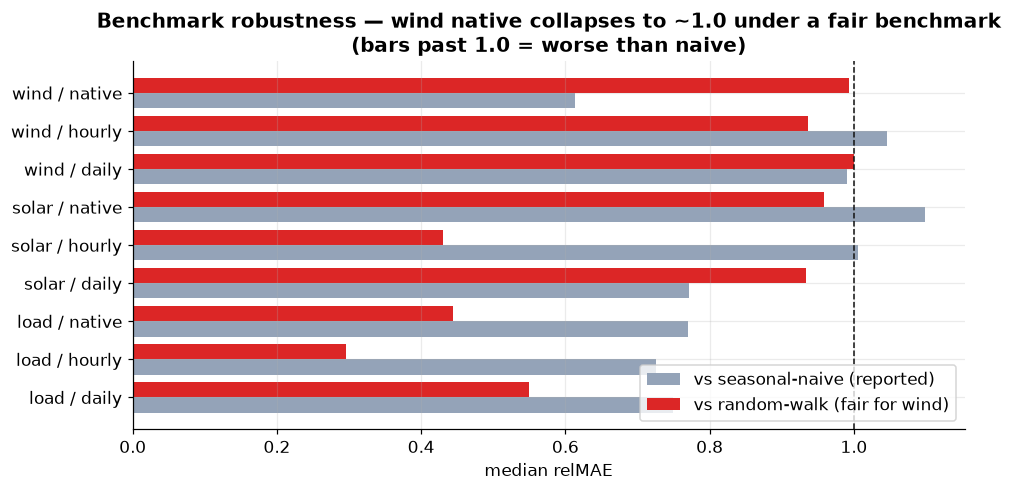

Wind native: seasonal 0.614  ->  random-walk 0.994
Finding: foundation models do NOT beat a random walk on high-frequency wind.


In [15]:
k = load("refined_stage3k_benchmark_comparison.csv")
if k is not None:
    k=k.copy(); k['cell']=k.etype+' / '+k.gran.map(lambda x:GLAB.get(x,x))
    yy=np.arange(len(k))
    fig,ax=plt.subplots(figsize=(9,4.6))
    ax.barh(yy-0.2,k.relMAE_seasonal,0.4,label='vs seasonal-naive (reported)',color='#94a3b8')
    ax.barh(yy+0.2,k.relMAE_randomwalk,0.4,label='vs random-walk (fair for wind)',color='#dc2626')
    ax.axvline(1,color='#111',ls='--',lw=1); ax.set_yticks(yy); ax.set_yticklabels(k.cell)
    ax.set_xlabel('median relMAE'); ax.legend(loc='lower right')
    ax.set_title('Benchmark robustness — wind native collapses to ~1.0 under a fair benchmark\n(bars past 1.0 = worse than naive)',fontweight='bold')
    plt.tight_layout(); plt.show()
    w=k[(k.etype=='wind')&(k.gran=='native')].iloc[0]
    print(f"Wind native: seasonal {w.relMAE_seasonal:.3f}  ->  random-walk {w.relMAE_randomwalk:.3f}")
    print("Finding: foundation models do NOT beat a random walk on high-frequency wind.")

## 9. H4 — Zero-inflation and aggregation (solar natural experiment)

Solar output is exactly zero at night (~55% of native samples). Aggregating to daily removes the
zeros entirely — and accuracy is restored. A clean natural experiment supporting H4 (for solar).

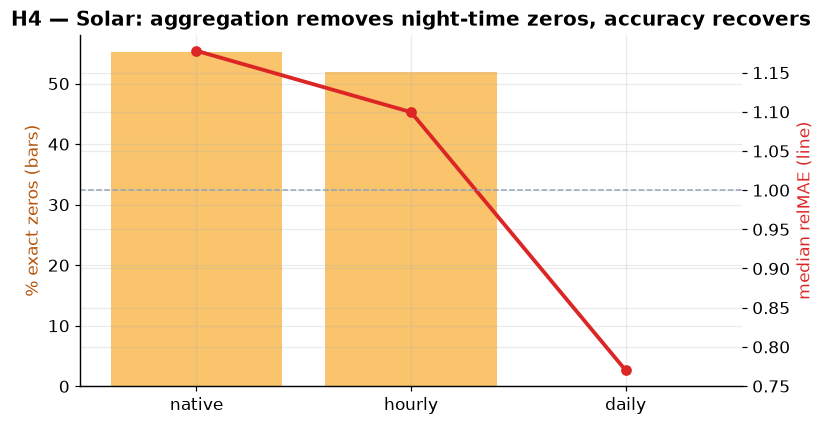

solar %zeros: {'native': 55.3, '1h': 51.9, '1D': 0.0}


In [16]:
a = load("refined_stage3a_characteristics.csv")
b_ = clean(load("refined_stage3b_context_sweep.csv")); c_ = clean(load("refined_stage3c_horizon_sweep.csv"))
if a is not None:
    z=a.groupby(['etype','gran']).pct_zero.mean().unstack()
    solz=[z.loc['solar','native'],z.loc['solar','1h'],z.loc['solar','1D']]
    solr=[b_[(b_.etype=='solar')&(b_.gran=='native')].relMAE.median(),
          b_[(b_.etype=='solar')&(b_.gran=='1h')].relMAE.median(),
          c_[(c_.etype=='solar')&(c_.gran=='1D')].relMAE.median()]
    fig,ax=plt.subplots(figsize=(7.5,4)); ax2=ax.twinx()
    xx=['native','hourly','daily']
    ax.bar(xx,solz,color='#f59e0b',alpha=0.6); ax2.plot(xx,solr,marker='o',color='#dc2626',lw=2.5)
    ax2.axhline(1,color='#94a3b8',ls='--',lw=1)
    ax.set_ylabel('% exact zeros (bars)',color='#b45309'); ax2.set_ylabel('median relMAE (line)',color='#dc2626')
    ax.set_title('H4 — Solar: aggregation removes night-time zeros, accuracy recovers',fontweight='bold')
    plt.tight_layout(); plt.show()
    print("solar %zeros:", {g:round(z.loc['solar',g],1) for g in ['native','1h','1D']})

## 10. Methodological corrections (contributions of general relevance)

Two corrections changed reported numbers and generalise beyond this thesis:

1. **A scale-free metric computed on the context window confounds the treatment.** The original MASE
   denominator changed as the sweep changed the context. Fixed → wind native median MASE fell from
   19.677 to 0.309. Primary metric switched to relMAE.
2. **Fixing the evaluation *window count* instead of *duration* under-powers high-frequency cells.**
   One window spans `horizon × step_minutes` of real time — 5 windows = 2.5 days of load but 2 hours
   of wind. Re-running with planned window counts **reversed the sign of the context effect in 3 of 7
   cells** and raised Holm-surviving context tests from 4 to 25.

The cell below shows the window-count sensitivity directly.

In [17]:
for f,label in [("refined_stage3b_window_count_sensitivity.csv","3B context effect"),
                ("refined_stage3d_window_count_sensitivity.csv","3D granularity winner")]:
    s=load(f)
    if s is not None:
        print(f"=== {label}: 5-window vs planned-window ===")
        print(s.round(3).to_string(index=False)); print()

=== 3B context effect: 5-window vs planned-window ===
etype       gran_label  ctx_lo_o  ctx_hi_o  old_lo  old_hi  old_5win  ctx_lo_n  ctx_hi_n  new_lo  new_hi  new_planned  sign_flip
 load            daily       128      2048   0.938   0.803    14.447       128      2048   0.851   0.605       28.914      False
 load           hourly       128      2048   1.057   0.827    21.743       128      2048   0.979   0.862       11.949      False
 load minutes (native)       128      2048   1.135   1.162    -2.376       128      2048   1.043   0.719       31.077       True
solar           hourly       128      2048   0.983   1.056    -7.435       128      2048   1.146   1.110        3.173       True
solar minutes (native)       128      2048   1.057   1.098    -3.913       128      2048   1.193   1.158        2.995       True
 wind           hourly       128      2048   1.039   1.139    -9.634       128      2048   1.040   1.224      -17.683      False
 wind minutes (native)       128      2048 


### Pretraining contamination audit (disclose in the methodology)

"Zero-shot" is best framed as **"no task-specific fine-tuning"**: some evaluation datasets appear in
the models' pretraining corpora. This must be disclosed, but it does **not** drive the conclusions.

| dataset | in a model's pretraining corpus? |
|---|---|
| `australian_electricity_demand` (load) | Yes — Moirai's LOTSA corpus |
| `wind_farms` (wind) | Yes — Moirai's LOTSA corpus |
| solar (al-pv-2006) & wind | In Chronos's pretraining group |
| TimesFM-2.5 (GiftEvalPretrain) | Probably cleanest; unresolved |

> **Key point for the defence:** the *most* contaminated model (Moirai) is the *worst* performer, and
> the cleanest-looking (TimesFM) is the best — the opposite of what leakage-driven results would show.
> Contamination therefore does not explain the findings.


## 11. Hypotheses — final verdicts

| # | hypothesis | verdict |
|---|---|---|
| H1 | granularity affects accuracy | **Supported**, conditional on lead time (6/13 significant) |
| H2 | config effects interact with granularity | **Underpowered at n=5** (0/6 Holm; direction consistent) |
| ~~H3~~ | context must span the dominant seasonal cycle | **REFUTED** — was built on the MASE bug; the "catastrophe" it explained never existed |
| H3′ | context benefit tracks *deterministic structure* in the signal | **Supported** (load improves to 2048; wind harmed by context) |
| H4 | zero-inflation degrades accuracy; aggregation reverses it | **Supported for solar**; does not generalise to wind |
| H5 | accuracy-optimal ≠ cost-optimal | **Supported** (Chronos dominates solar/wind frontiers) |
| H6 | descriptors transfer across energy types | **Partial** (2 of 3) |

> **H3's refutation is a headline result, not a failure.** It was the thesis's stated mechanistic
> core, built to explain a wind-native "catastrophe" that turned out to be the metric bug. H3′
> replaces it with a stronger claim that predicts the *sign* of the context effect from a measurable
> property of the signal.

## 12. Conclusions

1. **Optimal temporal granularity tracks forecast lead time** — aggregate the signal to roughly match
   how far ahead you forecast. Very short-term forecasting is granularity-invariant.
2. **The value of context is governed by how much deterministic structure a signal carries**, not by
   seasonal-cycle coverage. Demand rewards long history; wind is harmed by it.
3. **The accuracy-optimal model is not the cost-optimal one.** Once inference cost counts, Chronos
   dominates the solar and wind deployment frontiers despite TimesFM's higher raw accuracy.
4. **Deployability on an unseen energy type is predictable from series descriptors** for types of
   comparable behavioural variety (load, solar); it fails onto a near-homogeneous type (wind).
5. **Two methodological contributions**: a scale-free metric on the context window confounds the
   treatment; and fixing window count rather than duration under-powers high-frequency evaluation —
   enough to reverse a reported effect.
6. **A key negative result**: zero-shot foundation models do **not** beat a random walk on
   high-frequency wind; the apparent skill was a benchmark artefact.

### Limitations (for the write-up)
- Five series per energy type caps statistical power (load is archive-capped at 5).
- Model capacity is confounded with identity (all small variants).
- Two models were pretrained on corpora including these datasets → report as *"no task-specific
  fine-tuning"* rather than strict zero-shot; add a contamination audit table.

*This notebook reads only the existing `refined_stage*.csv` result files and runs no models. Every
figure is reproducible in seconds from the committed results.*